In [1]:
import pandas as pd

df = pd.read_csv("fed30_futures.csv")
df = df.sort_values(["FutCode", "Date_"])

# Drop columns where every row has the same value
constant_cols = [col for col in df.columns if df[col].nunique() <= 1]
df = df.drop(columns=constant_cols)

# Deduplicate (price columns store random codes)
df = df.drop(columns=['P'])
df = df.drop_duplicates(subset=['FutCode', 'Date_'])

# Compact: Remove ContrCode, ClsCode, ContrName, UnitCode
df = df.drop(columns=['ContrCode', 'ClsCode', 'ContrName', 'UnitCode', 'UnitDesc'])

df.to_csv("effr_futures.csv", index=False)

In [2]:

# Create "months.csv"
import csv
import calendar
from datetime import datetime, date

# Load decision dates from Prediction_all.csv, keep latest per month
decision_by_month = {}
with open('Prediction_all.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        d = datetime.strptime(row['decision_date'], '%Y-%m-%d').date()
        key = (d.year, d.month)
        if key not in decision_by_month or d > decision_by_month[key]:
            decision_by_month[key] = d

# Month range: Feb 2023 to Jun 2026
months = []
y, m = 2023, 2
while (y, m) <= (2026, 6):
    months.append((y, m))
    m += 1
    if m > 12:
        m = 1
        y += 1

rows = []
for (y, m) in months:
    month_label = date(y, m, 1).strftime('%Y-%m')
    total_days = calendar.monthrange(y, m)[1]
    if (y, m) in decision_by_month:
        dec_day = decision_by_month[(y, m)].day
        days_before_incl = dec_day
        days_after = total_days - dec_day
        fraction = days_before_incl / total_days
        rows.append([month_label, 'Y', days_before_incl, days_after, total_days, round(fraction, 6)])
    else:
        rows.append([month_label, 'N', '', '', '', ''])

with open('months.csv', 'w', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['month', 'decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl'])
    writer.writerows(rows)

print("Written months.csv")
for r in rows:
    print(r)


Written months.csv
['2023-02', 'Y', 1, 27, 28, 0.035714]
['2023-03', 'Y', 22, 9, 31, 0.709677]
['2023-04', 'N', '', '', '', '']
['2023-05', 'Y', 2, 29, 31, 0.064516]
['2023-06', 'Y', 13, 17, 30, 0.433333]
['2023-07', 'Y', 25, 6, 31, 0.806452]
['2023-08', 'N', '', '', '', '']
['2023-09', 'Y', 20, 10, 30, 0.666667]
['2023-10', 'Y', 31, 0, 31, 1.0]
['2023-11', 'N', '', '', '', '']
['2023-12', 'Y', 13, 18, 31, 0.419355]
['2024-01', 'Y', 31, 0, 31, 1.0]
['2024-02', 'N', '', '', '', '']
['2024-03', 'Y', 18, 13, 31, 0.580645]
['2024-04', 'Y', 30, 0, 30, 1.0]
['2024-05', 'N', '', '', '', '']
['2024-06', 'Y', 12, 18, 30, 0.4]
['2024-07', 'Y', 31, 0, 31, 1.0]
['2024-08', 'N', '', '', '', '']
['2024-09', 'Y', 18, 12, 30, 0.6]
['2024-10', 'N', '', '', '', '']
['2024-11', 'Y', 7, 23, 30, 0.233333]
['2024-12', 'Y', 18, 13, 31, 0.580645]
['2025-01', 'Y', 29, 2, 31, 0.935484]
['2025-02', 'N', '', '', '', '']
['2025-03', 'Y', 19, 12, 31, 0.612903]
['2025-04', 'N', '', '', '', '']
['2025-05', 'Y', 7, 24

In [3]:

# Create "rate_from_future.csv"
import csv

# Load months.csv into a dict keyed by (year, month)
months_info = {}
with open('months.csv') as f:
    reader = csv.DictReader(f)
    for row in reader:
        y, m = map(int, row['month'].split('-'))
        months_info[(y, m)] = row  # keys: decision, days_up_to_incl, days_after, total_days, frac_up_to_incl

def parse_contrdate(cd):
    """ContrDate is MMYY (no leading zero): e.g. 225 -> (2025, 2), 1023 -> (2023, 10)"""
    cd = int(cd)
    month = cd // 100
    year = 2000 + (cd % 100)
    return year, month

def prev_month(y, m):
    return (y - 1, 12) if m == 1 else (y, m - 1)

def next_month(y, m):
    return (y + 1, 1) if m == 12 else (y, m + 1)

# First pass: load all rows and build lookup {(date_str, (year, month)): Monthly_Rate}
all_rows = []
rate_lookup = {}  # (date_str, (year, month)) -> Monthly_Rate float
with open('effr_futures.csv') as fin:
    reader = csv.DictReader(fin)
    original_fieldnames = reader.fieldnames
    for row in reader:
        ym = parse_contrdate(row['ContrDate'])
        info = months_info.get(ym, {})
        months_cols = ['decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl']
        for col in months_cols:
            row[col] = info.get(col, '')
        try:
            mr = round(100 - float(row['Settlement']), 6)
            row['Monthly_Rate'] = mr
        except (ValueError, TypeError):
            row['Monthly_Rate'] = ''
            mr = None
        row['_ym'] = ym  # temp field
        all_rows.append(row)
        if mr is not None:
            rate_lookup[(row['Date_'], ym)] = mr

# Second pass: compute Hike_from_prev, Hike_to_next, and Hike
months_cols = ['decision', 'days_up_to_incl', 'days_after', 'total_days', 'frac_up_to_incl']
fieldnames = original_fieldnames + months_cols + ['Monthly_Rate', 'Hike_from_prev', 'Hike_to_next', 'Hike']

with open('rate_from_future.csv', 'w', newline='') as fout:
    writer = csv.DictWriter(fout, fieldnames=fieldnames, extrasaction='ignore')
    writer.writeheader()
    for row in all_rows:
        ym = row['_ym']
        hike_from_prev = ''
        hike_to_next = ''
        if row['decision'] == 'Y':
            try:
                frac = float(row['frac_up_to_incl'])
                curr_rate = float(row['Monthly_Rate'])
                date_ = row['Date_']

                pym = prev_month(*ym)
                if months_info.get(pym, {}).get('decision') == 'N':
                    prev_rate = rate_lookup.get((date_, pym))
                    if prev_rate is not None and (1 - frac) != 0:
                        hike_from_prev = round((curr_rate - prev_rate) / (1 - frac), 6)

                nym = next_month(*ym)
                if months_info.get(nym, {}).get('decision') == 'N':
                    next_rate = rate_lookup.get((date_, nym))
                    if next_rate is not None and frac != 0:
                        hike_to_next = round((next_rate - curr_rate) / frac, 6)
            except (ValueError, TypeError):
                pass

        row['Hike_from_prev'] = hike_from_prev
        row['Hike_to_next'] = hike_to_next

        if hike_from_prev != '' and hike_to_next != '':
            row['Hike'] = round((hike_from_prev + hike_to_next) / 2, 6)
        elif hike_from_prev != '':
            row['Hike'] = hike_from_prev
        elif hike_to_next != '':
            row['Hike'] = hike_to_next
        else:
            row['Hike'] = ''

        writer.writerow(row)

print("Written rate_from_future.csv")

# DFF fallback: for rows observed within the contract's own month,
# the prior month's futures have expired. Use actual DFF as R0.
import csv as _csv
from datetime import datetime as _dt, timedelta as _td

_dff = {}
with open('DFF.csv') as _f:
    for _row in _csv.DictReader(_f):
        _dff[_row['observation_date']] = float(_row['DFF'])

def _prior_dff(date_str):
    d = _dt.strptime(date_str, '%Y-%m-%d').date()
    for i in range(1, 10):
        prior = (d - _td(days=i)).strftime('%Y-%m-%d')
        if prior in _dff:
            return _dff[prior]
    return None

_updated = 0
_rows2 = []
with open('rate_from_future.csv') as _f:
    _reader = _csv.DictReader(_f)
    _fn = _reader.fieldnames
    for _row in _reader:
        if _row['decision'] == 'Y' and _row['Hike'] == '':
            _cy, _cm = parse_contrdate(_row['ContrDate'])
            _d = _dt.strptime(_row['Date_'], '%Y-%m-%d')
            if _d.year == _cy and _d.month == _cm:
                _mr, _frac = _row['Monthly_Rate'], _row['frac_up_to_incl']
                if _mr != '' and _frac != '':
                    _r0 = _prior_dff(_row['Date_'])
                    if _r0 is not None:
                        _h = round((float(_mr) - _r0) / (1 - float(_frac)), 6)
                        _row['Hike_from_prev'] = _h
                        _row['Hike'] = _h
                        _updated += 1
        _rows2.append(_row)

with open('rate_from_future.csv', 'w', newline='') as _f:
    _w = _csv.DictWriter(_f, fieldnames=_fn)
    _w.writeheader()
    _w.writerows(_rows2)

print(f"DFF fallback applied to {_updated} in-month rows")


Written rate_from_future.csv


DFF fallback applied to 103 in-month rows


In [4]:

# Create "expectations.csv"
import csv
from datetime import datetime

# Outcome values in % (not basis points, consistent with futures)
KALSHI_OUTCOMES = {
    'kalshi_C25':  -0.25,
    'kalshi_C50+': -0.75,
    'kalshi_H0':    0.00,
    'kalshi_H25':  +0.25,
    'kalshi_H50':  +0.50,
    'kalshi_H50+': +0.75,
}
POLY_OUTCOMES = {
    'polymarket_C25':   -0.25,
    'polymarket_C50':   -0.50,
    'polymarket_C50+':  -0.75,
    'polymarket_C75+':  -0.75,
    'polymarket_H0':     0.00,
    'polymarket_H25':   +0.25,
    'polymarket_H25+':  +0.25,
    'polymarket_H50':   +0.50,
    'polymarket_H50+':  +0.75,
    'polymarket_H75':   +0.75,
}

def weighted_avg(row, outcome_map, min_total=0.5):
    vals = {col: float(row[col]) for col in outcome_map if row.get(col)}
    if not vals:
        return ''
    total = sum(vals.values())
    if total < min_total:
        return ''  # incomplete scrape — probabilities don't sum near 1
    return round(sum(p * outcome_map[col] for col, p in vals.items()) / total, 6)

# Build futures Hike lookup: (observed_date, contract_year, contract_month) -> Hike
def parse_contrdate(cd):
    cd = int(cd)
    return 2000 + (cd % 100), cd // 100

futures_lookup = {}  # (date_str, year, month) -> Hike
with open('rate_from_future.csv') as f:
    for row in csv.DictReader(f):
        y, m = parse_contrdate(row['ContrDate'])
        key = (row['Date_'], y, m)
        if row['Hike'] != '':
            futures_lookup[key] = float(row['Hike'])

# Build output
with open('Prediction_all.csv') as fin, open('expectations.csv', 'w', newline='') as fout:
    reader = csv.DictReader(fin)
    writer = csv.DictWriter(fout, fieldnames=['decision_date', 'observed_day_pst',
                                               'Polymarket_Exp', 'Kalshi_Exp', 'Futures_Hike'])
    writer.writeheader()
    for row in reader:
        d = datetime.strptime(row['decision_date'], '%Y-%m-%d')
        key = (row['observed_day_pst'], d.year, d.month)
        writer.writerow({
            'decision_date':    row['decision_date'],
            'observed_day_pst': row['observed_day_pst'],
            'Polymarket_Exp':   weighted_avg(row, POLY_OUTCOMES),
            'Kalshi_Exp':       weighted_avg(row, KALSHI_OUTCOMES),
            'Futures_Hike':     futures_lookup.get(key, ''),
        })

print("Written expectations.csv")


Written expectations.csv


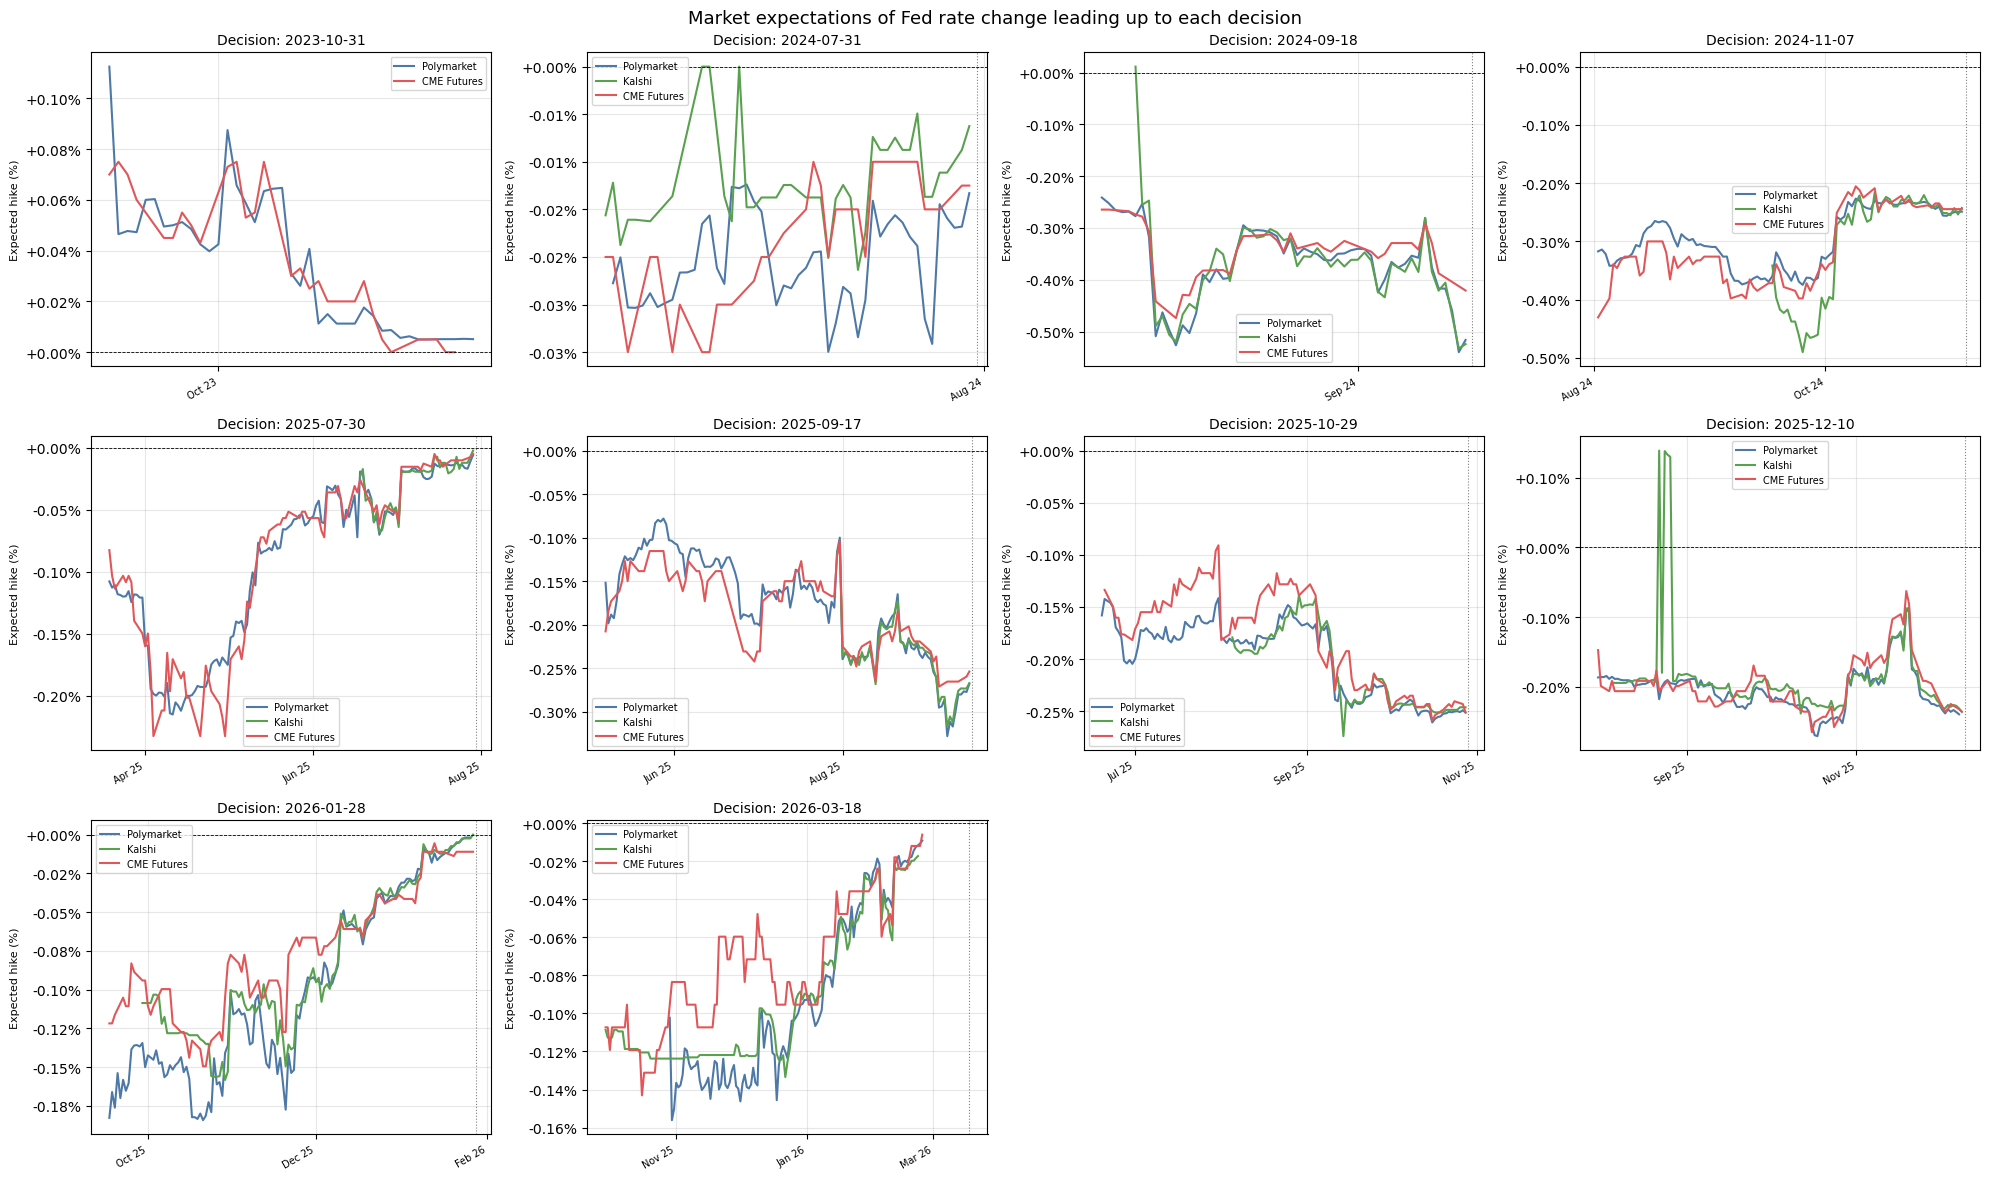

In [5]:

# Plot expectations leading up to decision for all isolatable decisions
import csv
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Only include decisions that: (1) have Futures_Hike data, (2) futures coverage >19%
# (excludes DFF-fallback-only decisions), and (3) last observation is within 30 days
# of the decision (excludes far-future decisions with incomplete series)
import collections as _col
_cov = _col.defaultdict(lambda: {'total': 0, 'futures': 0, 'last_obs': None})
with open('expectations.csv') as _f:
    _rows = list(csv.DictReader(_f))
for _r in _rows:
    _dd = _r['decision_date']
    _obs = datetime.strptime(_r['observed_day_pst'], '%Y-%m-%d').date()
    _cov[_dd]['total'] += 1
    if _r['Futures_Hike']:
        _cov[_dd]['futures'] += 1
    if _cov[_dd]['last_obs'] is None or _obs > _cov[_dd]['last_obs']:
        _cov[_dd]['last_obs'] = _obs
DECISION_DATES = sorted(
    dd for dd, c in _cov.items()
    if c['futures'] > 0
    and c['futures'] / c['total'] > 0.20
    and (datetime.strptime(dd, '%Y-%m-%d').date() - c['last_obs']).days <= 30
)

# Load data grouped by decision date
with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

def parse_row(r):
    return {
        'obs':     datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
        'poly':    float(r['Polymarket_Exp'])  if r['Polymarket_Exp']  else None,
        'kalshi':  float(r['Kalshi_Exp'])      if r['Kalshi_Exp']      else None,
        'futures': float(r['Futures_Hike'])    if r['Futures_Hike']    else None,
    }

data = {dd: sorted([parse_row(r) for r in all_rows if r['decision_date'] == dd],
                   key=lambda x: x['obs'])
        for dd in DECISION_DATES}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, dd in zip(axes, DECISION_DATES):
    rows = data[dd]
    dec_date = datetime.strptime(dd, '%Y-%m-%d')

    for col, label, color in [('poly', 'Polymarket', '#4e79a7'),
                               ('kalshi', 'Kalshi', '#59a14f'),
                               ('futures', 'CME Futures', '#e15759')]:
        xs = [r['obs'] for r in rows if r[col] is not None]
        ys = [r[col]   for r in rows if r[col] is not None]
        if xs:
            ax.plot(xs, ys, label=label, color=color, linewidth=1.5)

    ax.axhline(0, color='black', linewidth=0.6, linestyle='--')
    ax.axvline(dec_date, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(f'Decision: {dd}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.2f}%'))
    ax.set_ylabel('Expected hike (%)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

for ax in axes[len(DECISION_DATES):]:
    ax.set_visible(False)

fig.suptitle('Market expectations of Fed rate change leading up to each decision', fontsize=13)
plt.tight_layout()
plt.show()


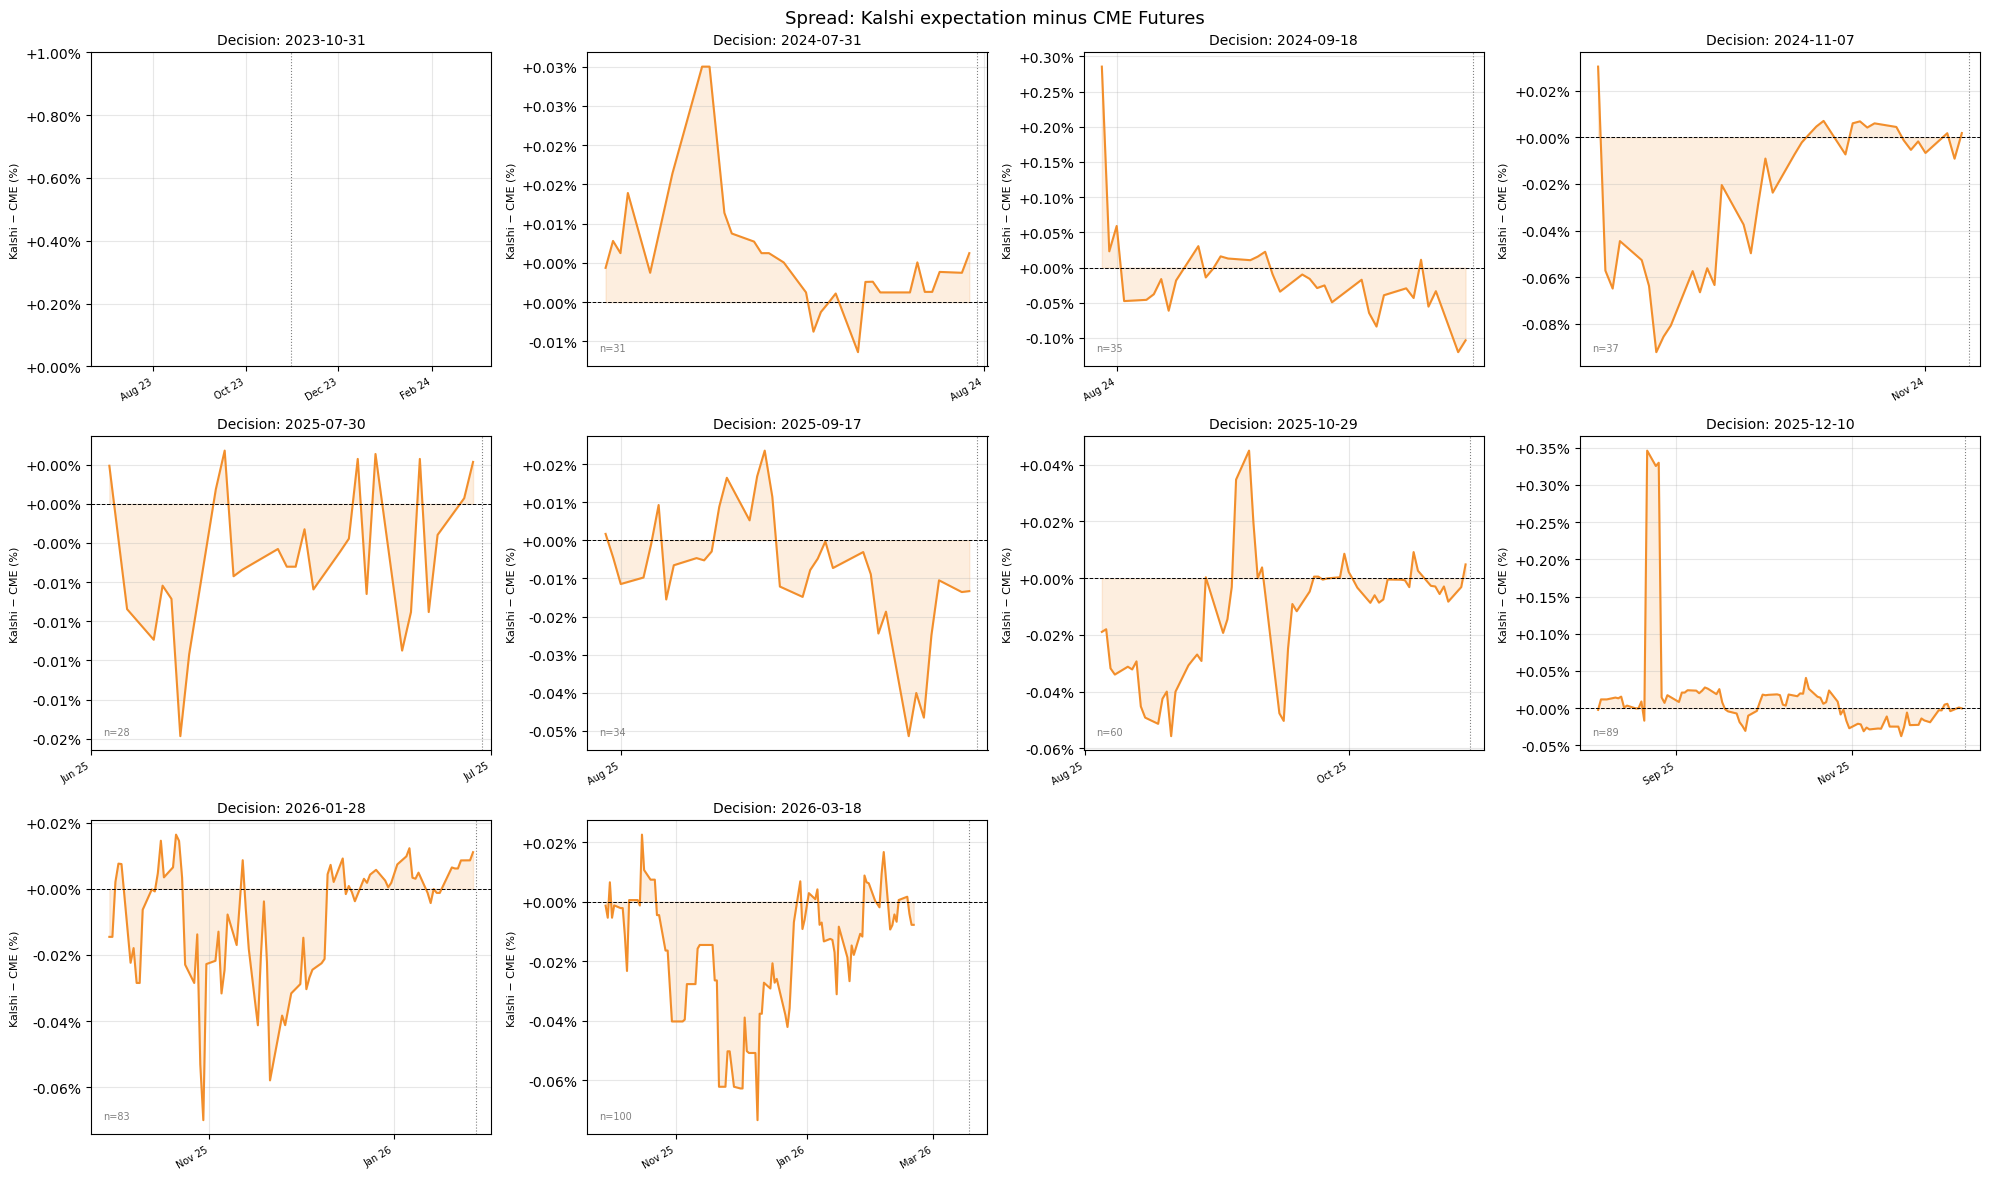

In [6]:

# Plot Kalshi minus CME Futures spread for all isolatable decisions
import csv
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Only include decisions that: (1) have Futures_Hike data, (2) futures coverage >19%
# (excludes DFF-fallback-only decisions), and (3) last observation is within 30 days
# of the decision (excludes far-future decisions with incomplete series)
import collections as _col
_cov = _col.defaultdict(lambda: {'total': 0, 'futures': 0, 'last_obs': None})
with open('expectations.csv') as _f:
    _rows = list(csv.DictReader(_f))
for _r in _rows:
    _dd = _r['decision_date']
    _obs = datetime.strptime(_r['observed_day_pst'], '%Y-%m-%d').date()
    _cov[_dd]['total'] += 1
    if _r['Futures_Hike']:
        _cov[_dd]['futures'] += 1
    if _cov[_dd]['last_obs'] is None or _obs > _cov[_dd]['last_obs']:
        _cov[_dd]['last_obs'] = _obs
DECISION_DATES = sorted(
    dd for dd, c in _cov.items()
    if c['futures'] > 0
    and c['futures'] / c['total'] > 0.20
    and (datetime.strptime(dd, '%Y-%m-%d').date() - c['last_obs']).days <= 30
)

with open('expectations.csv') as f:
    all_rows = list(csv.DictReader(f))

def parse_row(r):
    return {
        'obs':     datetime.strptime(r['observed_day_pst'], '%Y-%m-%d'),
        'kalshi':  float(r['Kalshi_Exp'])   if r['Kalshi_Exp']   else None,
        'futures': float(r['Futures_Hike']) if r['Futures_Hike'] else None,
    }

data = {dd: sorted([parse_row(r) for r in all_rows if r['decision_date'] == dd],
                   key=lambda x: x['obs'])
        for dd in DECISION_DATES}

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for ax, dd in zip(axes, DECISION_DATES):
    rows = data[dd]
    dec_date = datetime.strptime(dd, '%Y-%m-%d')

    xs = [r['obs'] for r in rows if r['kalshi'] is not None and r['futures'] is not None]
    ys = [r['kalshi'] - r['futures'] for r in rows
          if r['kalshi'] is not None and r['futures'] is not None]

    if xs:
        ax.plot(xs, ys, color='#f28e2b', linewidth=1.5)
        ax.fill_between(xs, ys, 0, alpha=0.15, color='#f28e2b')

    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.axvline(dec_date, color='grey', linewidth=0.8, linestyle=':')
    ax.set_title(f'Decision: {dd}', fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.2f}%'))
    ax.set_ylabel('Kalshi − CME (%)', fontsize=8)
    ax.grid(True, alpha=0.3)
    if xs:
        ax.annotate(f'n={len(xs)}', xy=(0.03, 0.05), xycoords='axes fraction', fontsize=7, color='grey')

for ax in axes[len(DECISION_DATES):]:
    ax.set_visible(False)

fig.suptitle('Spread: Kalshi expectation minus CME Futures', fontsize=13)
plt.tight_layout()
plt.show()
